**Business Problem:** A multinational technology organization wants to understand employee attrition drivers. Before predictive modelling, this notebook builds a complete feature engineering pipeline that transforms the raw HR dataset (5,000 employees, 39 variables) into a machine-learning-ready dataset.





**Structure**
* Part A - Understanding the Dataset
* Part B - Designing a Feature Engineering Strategy
* Part C - Feature Construction and Feature Selection
* Part D - Dimensionality Reduction and Pipeline Design
* Part E - Summary and Reflection
* Assignment report - in PDF

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

df = pd.read_csv('Assignment Dataset.csv')

# I have uploded the data file to my github, and called it through my link, if this didn't load change the adress to your copy of Assignmentof dataset file

print('Shape:', df.shape)
df.head()


Shape: (5000, 39)


,Employee_ID,Age,Gender,Marital_Status,Education_Level,Department,Job_Role,Total_Work_Experience,Years_at_Company,Years_in_Current_Role,Promotion_Count,Business_Travel,Work_Mode,Distance_From_Home,Monthly_Salary,Annual_Bonus,Stock_Option_Value,Overtime_Hours,Monthly_Expenses,Compensation_Band,Performance_Rating,Manager_Rating,Training_Hours,Certification_Count,Project_Count,Job_Satisfaction,Work_Life_Balance,Environment_Satisfaction,Relationship_Satisfaction,Recognition_Score,Manager_Support,Engagement_Index,Productivity_Index,Financial_Stress_Index,Attendance_Score,Career_Growth_Index,Annual_Compensation,Experience_Band,Attrition
0,EMP100001,37,Male,Single,Bachelor,Engineering,Senior Engineer,15,7.8,5.0,2,Frequently,Hybrid,19.2,11032.61,17422.14,151484.41,4.7,5288.23,Medium,4,4.0,35.1,3,3,6,5,7.0,6,7,7,6.50,53.59,44.11,92.84,52.99,301297.87,Mid,0
1,EMP100002,27,Male,Single,Bachelor,Operations,Engineer,2,2.0,0.1,0,Never,Office,6.1,5953.93,14494.60,0.00,10.8,4232.64,Low,3,3.0,NaN,0,1,6,5,5.0,5,5,5,5.25,39.22,85.62,88.21,14.41,85941.76,Entry,0
2,EMP100003,41,Male,Married,Master,Finance,Manager,15,4.7,0.2,1,Frequently,Hybrid,4.9,22053.98,19612.16,232221.91,1.3,11040.13,High,3,4.0,31.8,0,8,6,4,6.0,4,9,4,5.75,49.53,36.18,90.69,36.18,516481.83,Mid,0
3,EMP100004,43,Male,Divorced,Bachelor,Finance,Manager,23,3.0,0.8,0,Never,Hybrid,15.0,27033.46,137192.60,111808.68,1.3,16966.09,High,4,5.0,31.6,0,8,6,6,5.0,6,6,8,6.50,59.97,50.70,89.36,31.91,573402.80,Senior,0
4,EMP100005,21,Male,Single,Bachelor,HR,Associate,0,0.0,0.0,0,Rarely,Hybrid,15.7,3253.53,4228.73,0.00,3.4,1435.83,Low,3,3.0,20.4,0,2,5,4,5.0,4,5,4,4.50,39.32,44.69,90.01,14.34,43271.09,Entry,0


## Part A - Understanding the Dataset

### A.1 Structure and Feature Types


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Employee_ID                5000 non-null   object 
 1   Age                        5000 non-null   int64  
 2   Gender                     5000 non-null   object 
 3   Marital_Status             5000 non-null   object 
 4   Education_Level            5000 non-null   object 
 5   Department                 5000 non-null   object 
 6   Job_Role                   5000 non-null   object 
 7   Total_Work_Experience      5000 non-null   int64  
 8   Years_at_Company           5000 non-null   float64
 9   Years_in_Current_Role      5000 non-null   float64
 10  Promotion_Count            5000 non-null   int64  
 11  Business_Travel            5000 non-null   object 
 12  Work_Mode                  5000 non-null   object 
 13  Distance_From_Home         5000 non-null   float

In [4]:
identifier_cols = ['Employee_ID']

nominal_cols = ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Business_Travel', 'Work_Mode']

ordinal_text_cols = ['Education_Level', 'Compensation_Band', 'Experience_Band']

ordinal_num_cols = ['Performance_Rating', 'Manager_Rating', 'Job_Satisfaction', 'Work_Life_Balance',
                       'Environment_Satisfaction', 'Relationship_Satisfaction', 'Recognition_Score',
                       'Manager_Support']

discrete_numeric_cols = ['Promotion_Count', 'Certification_Count', 'Project_Count']

continuous_numeric_cols = ['Age', 'Total_Work_Experience', 'Years_at_Company', 'Years_in_Current_Role',
                            'Distance_From_Home', 'Monthly_Salary', 'Annual_Bonus', 'Stock_Option_Value',
                            'Overtime_Hours', 'Monthly_Expenses', 'Training_Hours', 'Engagement_Index',
                            'Productivity_Index', 'Financial_Stress_Index', 'Attendance_Score',
                            'Career_Growth_Index', 'Annual_Compensation']

target_col = ['Attrition']

In [5]:
total_classified = (len(identifier_cols) + len(nominal_cols) + len(ordinal_text_cols) + len(ordinal_num_cols) +
                    len(discrete_numeric_cols) + len(continuous_numeric_cols) + len(target_col))
print('Total columns classified:', total_classified, '/', df.shape[1])

pd.DataFrame({
    'Category': ['Identifier', 'Nominal categorical', 'Ordinal (text)', 'Ordinal (num scores)',
                 'Discrete numeric (counts)', 'Continuous numeric', 'Target'],
    'Count': [len(identifier_cols), len(nominal_cols), len(ordinal_text_cols), len(ordinal_num_cols),
              len(discrete_numeric_cols), len(continuous_numeric_cols), len(target_col)]
})

Total columns classified: 39 / 39


,Category,Count
0,Identifier,1
1,Nominal categorical,6
2,Ordinal (text),3
3,Ordinal (num scores),8
4,Discrete numeric (counts),3
5,Continuous numeric,17
6,Target,1


Before finalizing this classification, we inspect the actual unique values behind each nominal and ordinal column. This is the evidence for why each was placed in its category, and confirms the ordinal columns take a small, ordered set of levels.

In [6]:
print('--- Nominal categorical columns ---')
for c in nominal_cols:
    print(f'{c} ({df[c].nunique()} levels):', sorted(df[c].dropna().unique()))

print()
print('--- Text-based ordinal columns ---')
for c in ordinal_text_cols:
    print(f'{c} ({df[c].nunique()} levels):', sorted(df[c].dropna().unique()))

print()
print('--- Numeric survey-score (ordinal) columns ---')
for c in ordinal_num_cols:
    vals = sorted(df[c].dropna().unique())
    print(f'{c} ({len(vals)} levels): min={vals[0]}, max={vals[-1]}')


--- Nominal categorical columns ---
Gender (3 levels): ['Female', 'Male', 'Non-Binary']
Marital_Status (3 levels): ['Divorced', 'Married', 'Single']
Department (7 levels): ['Engineering', 'Finance', 'HR', 'Marketing', 'Operations', 'Sales', 'Support']
Job_Role (6 levels): ['Associate', 'Engineer', 'Lead', 'Manager', 'Senior Engineer', 'Senior Manager']
Business_Travel (3 levels): ['Frequently', 'Never', 'Rarely']
Work_Mode (3 levels): ['Hybrid', 'Office', 'Remote']

--- Text-based ordinal columns ---
Education_Level (4 levels): ['Bachelor', 'Doctorate', 'High School', 'Master']
Compensation_Band (3 levels): ['High', 'Low', 'Medium']
Experience_Band (4 levels): ['Entry', 'Junior', 'Mid', 'Senior']

--- Numeric survey-score (ordinal) columns ---
Performance_Rating (5 levels): min=1, max=5
Manager_Rating (5 levels): min=1.0, max=5.0
Job_Satisfaction (10 levels): min=1, max=10
Work_Life_Balance (10 levels): min=1, max=10
Environment_Satisfaction (10 levels): min=1.0, max=10.0
Relationship_

**Observation:**
* The nominal columns have no inherent order (e.g. `Gender`: Male/Female/Non-Binary) - one-hot encoding is appropriate.
* The text-based columns `Education_Level` (4 levels), `Compensation_Band` (3 levels), and `Experience_Band` (4 levels) are naturally ordered despite being stored as text, so they need ordinal encoding with an explicit order.
* Among the numeric survey scores, `Performance_Rating` and `Manager_Rating` are 5-point scales (1-5) while the rest are 10-point scales (1-10), bounded Likert-style ratings rather than free continuous measurements.

### A.2 Missing Values

In [7]:
missing = df.isnull().sum()
missing_pr = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pr})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_%', ascending=False)
missing_summary


,Missing_Count,Missing_%
Training_Hours,350,7.0
Annual_Bonus,300,6.0
Manager_Rating,250,5.0
Environment_Satisfaction,250,5.0


We also observed these missing values in Part A1

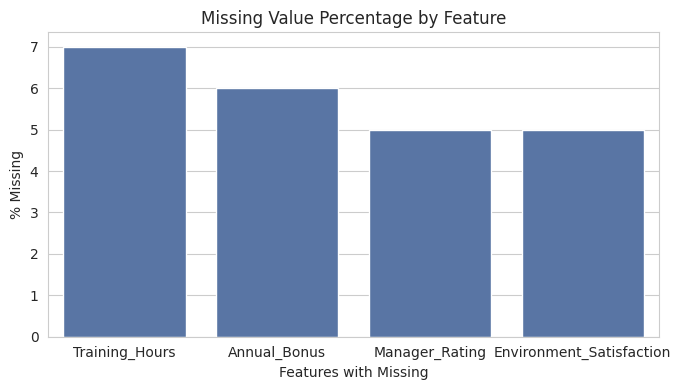

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=missing_summary.index, y=missing_summary['Missing_%'], ax=ax, color='#4C72B0')
ax.set_ylabel('% Missing')
ax.set_xlabel('Features with Missing')
ax.set_title('Missing Value Percentage by Feature')
plt.tight_layout()
plt.show()


In [9]:
for c in missing_summary.index:
    rate_missing = df.loc[df[c].isnull(), 'Attrition'].mean()
    rate_present = df.loc[df[c].notnull(), 'Attrition'].mean()
    print(f'{c:28s} attrition rate : missing={rate_missing:.3f}  present={rate_present:.3f}')


Training_Hours               attrition rate : missing=0.160  present=0.193
Annual_Bonus                 attrition rate : missing=0.210  present=0.189
Manager_Rating               attrition rate : missing=0.176  present=0.191
Environment_Satisfaction     attrition rate : missing=0.184  present=0.191


**Observation:** Four features have missing values (5-7% each): `Training_Hours`, `Annual_Bonus`, `Manager_Rating`, `Environment_Satisfaction`. Attrition rates are nearly identical between the missing and non-missing groups for every column, suggesting the missingness is unrelated to the target (consistent with Missing Completely At Random). This supports simple, direct imputation in Part B rather than more complex missing-pattern modelling.

### A.3 Target Variable Distribution

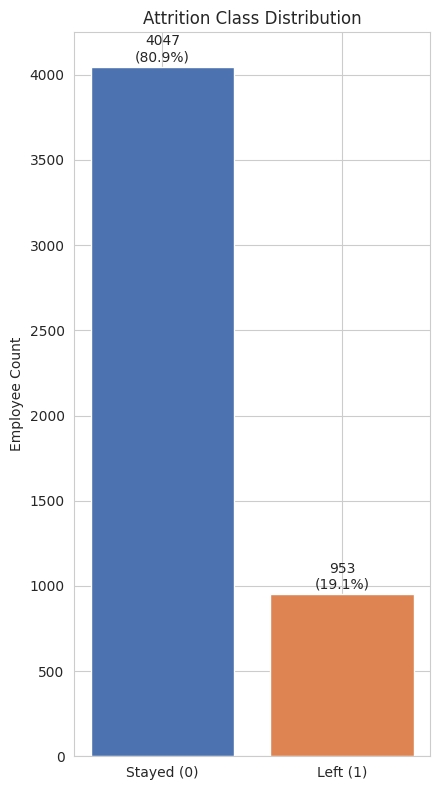

Attrition
0    0.809
1    0.191
Name: proportion, dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(4.5, 8))
counts = df['Attrition'].value_counts().sort_index()
ax.bar(['Stayed (0)', 'Left (1)'], counts.values, color=['#4C72B0', '#DD8452'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center')
ax.set_title('Attrition Class Distribution')
ax.set_ylabel('Employee Count')
plt.tight_layout()
plt.show()

print(df['Attrition'].value_counts(normalize=True).round(3))


**Observation:** The target is imbalanced - 80.9% Stayed vs 19.1% Left (i.e 4.2:1). This doesn't change feature engineering directly, but is worth flagging for downstream modelling. We should stratify splits wherever we split the data for this dataset.

### A.4 Numerical Distributions and Skewness

In [11]:
conti_n_disc = continuous_numeric_cols + discrete_numeric_cols
desc = df[conti_n_disc].describe().T
desc['skew'] = df[conti_n_disc].skew()
desc[['mean', 'std', 'min', 'max', 'skew']].sort_values('skew', ascending=False)


,mean,std,min,max,skew
Stock_Option_Value,130869.447020,231877.594476,0.00,2912175.45,3.380210
Annual_Bonus,36710.677534,36451.119511,176.62,408826.73,3.060238
Annual_Compensation,311756.250836,291100.244368,34518.63,3143384.72,2.163644
Monthly_Salary,11999.927000,7942.839669,2420.45,93069.80,2.142931
Years_in_Current_Role,1.715520,1.845140,0.00,15.80,1.923618
Distance_From_Home,15.356100,12.337019,0.10,103.50,1.895048
Overtime_Hours,8.974564,6.739951,0.10,54.21,1.611029
Monthly_Expenses,6780.904648,4487.457153,1107.46,36109.55,1.600538
Certification_Count,0.806200,0.969345,0.00,7.00,1.386466
Years_at_Company,3.410080,2.679753,0.00,17.10,1.152443


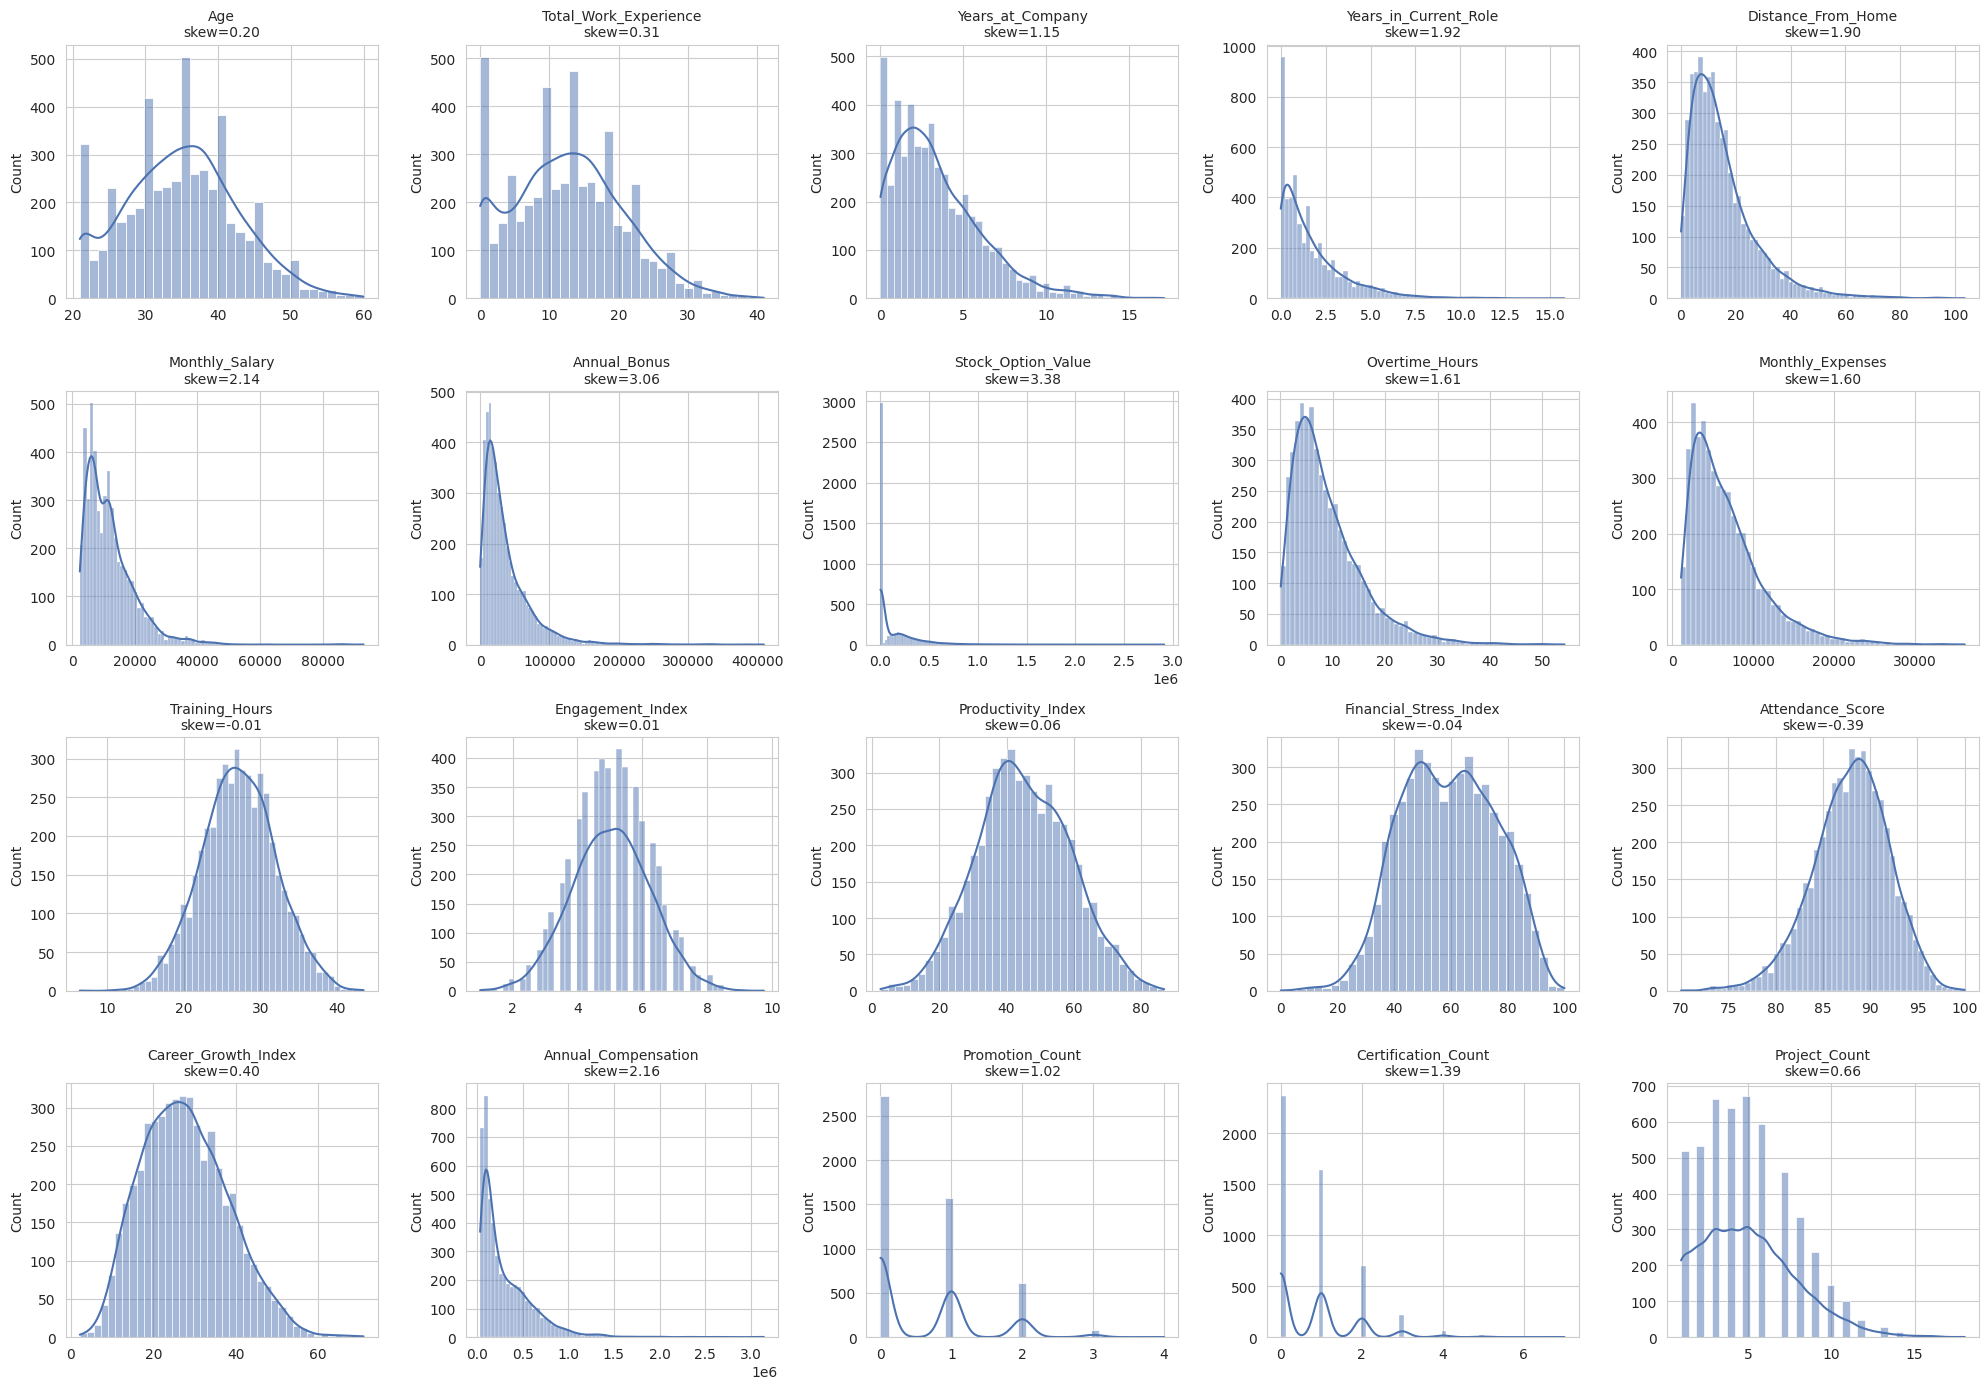

In [12]:
fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()
for i, c in enumerate(conti_n_disc):
    sns.histplot(df[c].dropna(), kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'{c}\nskew={df[c].skew():.2f}', fontsize=10)
    axes[i].set_xlabel('')
for j in range(len(conti_n_disc), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


**Observation:** Several compensation/tenure features are strongly right-skewed: `Stock_Option_Value`(3.4), `Annual_Bonus`(3.1), `Annual_Compensation`(2.2), `Monthly_Salary`(2.1), `Years_in_Current_Role`(1.9), `Distance_From_Home`(1.9), `Overtime_Hours`(1.6), `Monthly_Expenses`(1.6).<br>
This is typical of compensation/tenure data (most employees cluster low, with a long tail of senior/highly-paid staff) and points to log transforms being appropriate.<br>
`Engagement_Index`, `Productivity_Index`, `Financial_Stress_Index`, and `Age` are close to symmetric.

### A.5 Outlier Detection (IQR Method)

In [13]:
outlier_rows = []
for c in conti_n_disc:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    outlier_rows.append([c, round(lo, 1), round(hi, 1), n_out, round(n_out / len(df) * 100, 2)])

outlier_summary = pd.DataFrame(outlier_rows, columns=['Feature', 'Lower_Bound', 'Upper_Bound', 'Outlier_Count', 'Outlier_%'])
outlier_summary.sort_values('Outlier_%', ascending=False)


,Feature,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
7,Stock_Option_Value,-305760.8,509601.3,316,6.32
18,Certification_Count,-1.5,2.5,298,5.96
6,Annual_Bonus,-38077.8,99583.8,261,5.22
3,Years_in_Current_Role,-2.6,5.4,244,4.88
4,Distance_From_Home,-13.3,40.3,224,4.48
8,Overtime_Hours,-7.5,23.8,195,3.90
9,Monthly_Expenses,-4460.6,16765.1,188,3.76
5,Monthly_Salary,-7600.5,29413.3,163,3.26
16,Annual_Compensation,-429247.9,980081.3,156,3.12
2,Years_at_Company,-3.9,10.2,120,2.40


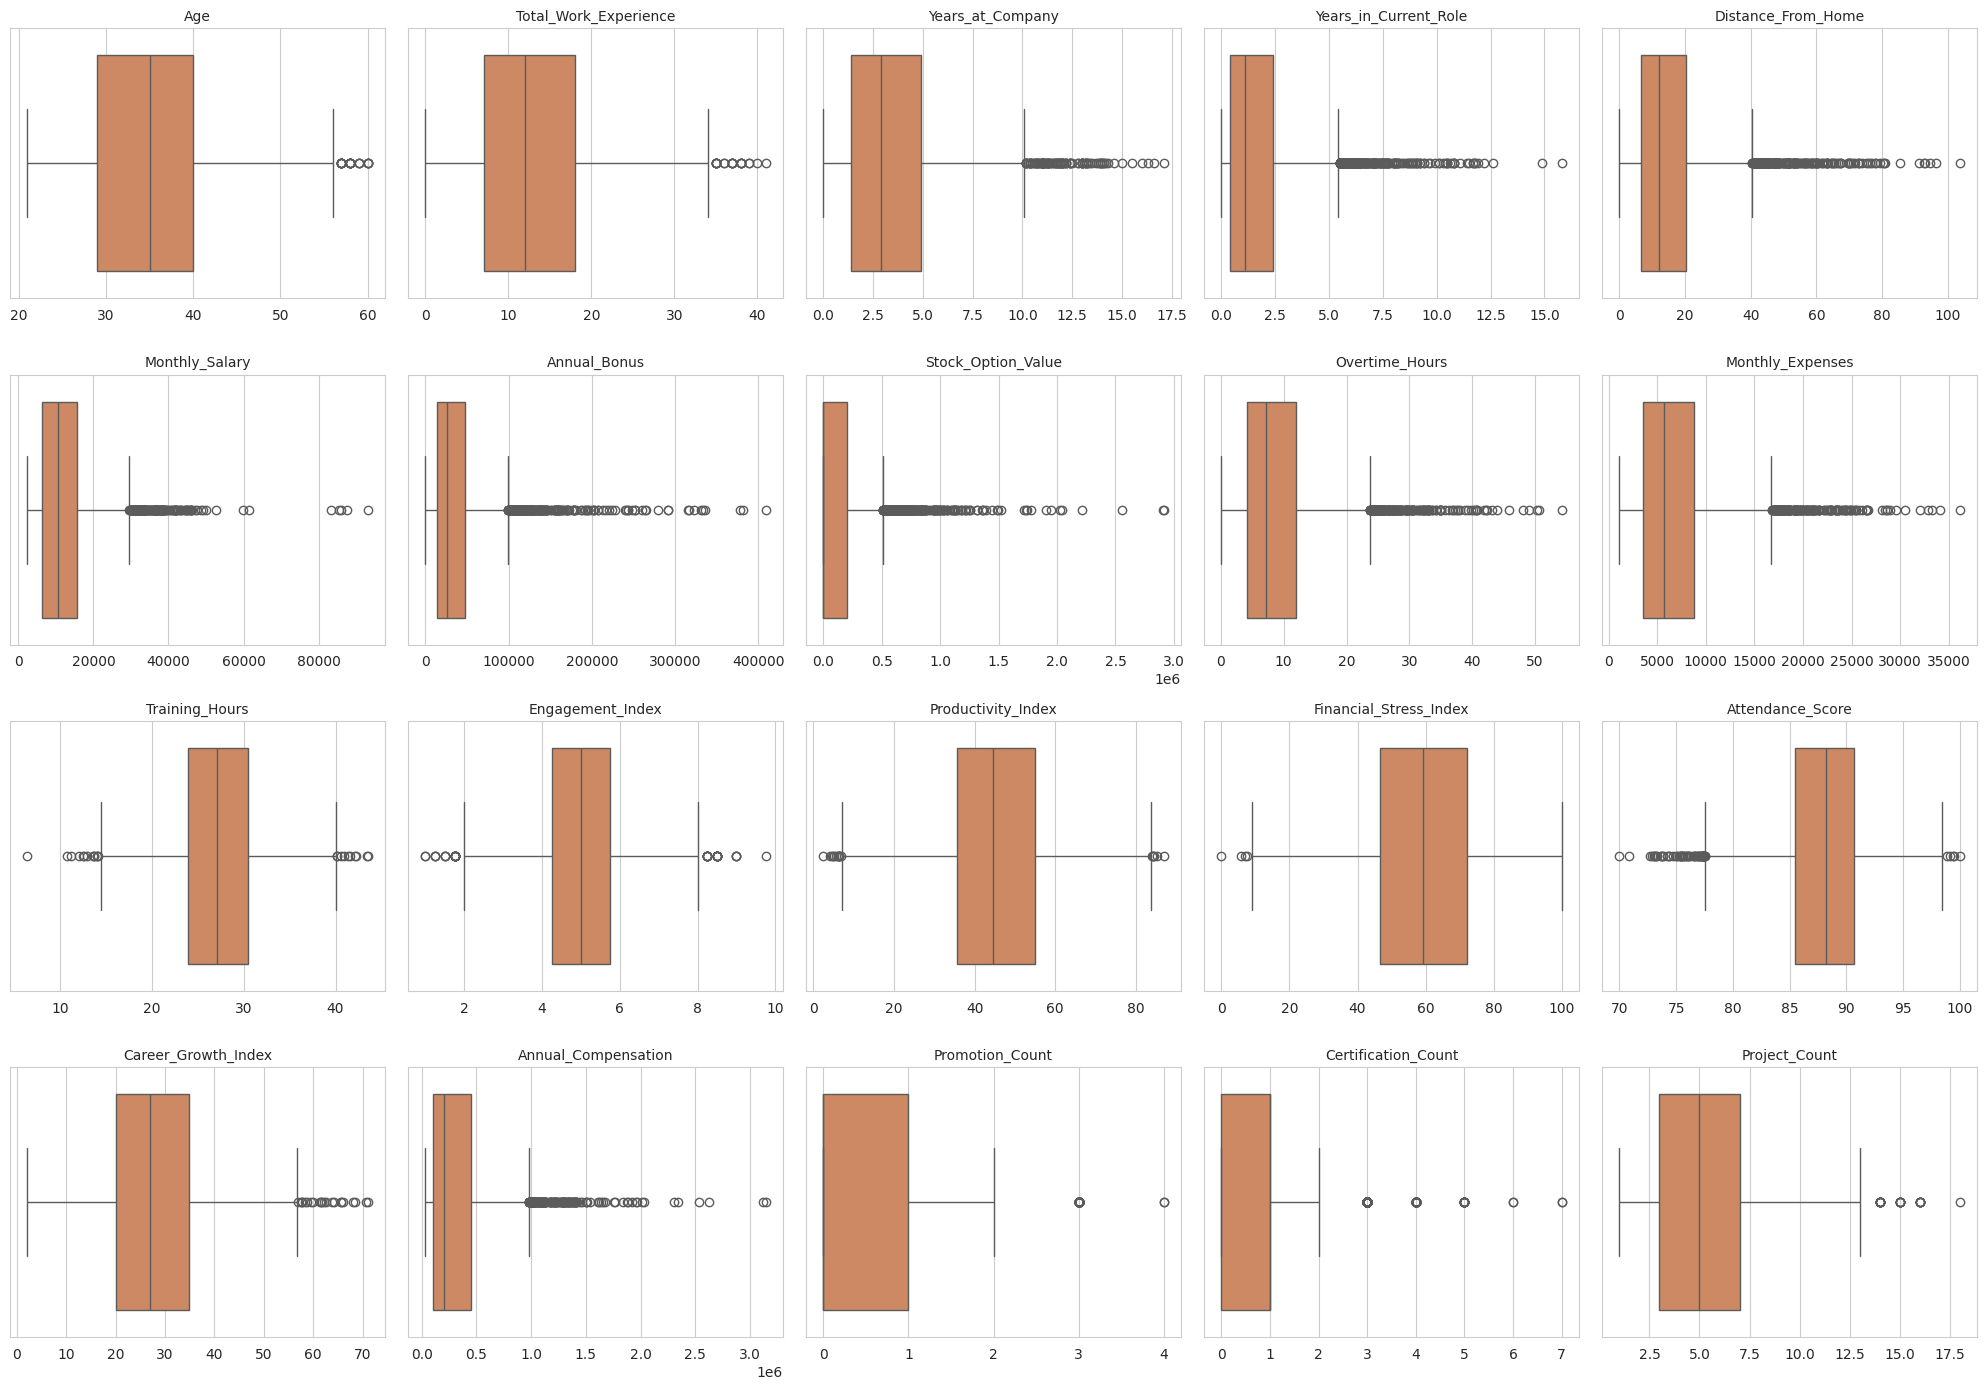

In [14]:
fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()
for i, c in enumerate(conti_n_disc):
    sns.boxplot(x=df[c], ax=axes[i], color='#DD8452')
    axes[i].set_title(c, fontsize=10)
    axes[i].set_xlabel('')
for j in range(len(conti_n_disc), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


**Observation:** Outlier rates (IQR method) range from under 0.5% up to 6% and are concentrated in the same right-skewed compensation/tenure features flagged above eg.(`Stock_Option_Value` 6.3%, `Annual_Bonus` 5.2%, `Years_in_Current_Role` 4.9%). <br>
These largely represent genuine senior/high-earning employees rather than data errors, so capping (winsorizing) is more appropriate than deleting rows, which would bias the dataset against exactly the employees who may be most informative for attrition.

### A.6 Relationships Between Numerical Features (Multicollinearity Check)

In [15]:
num_cols_corr = conti_n_disc + ordinal_num_cols
corr = df[num_cols_corr].corr()

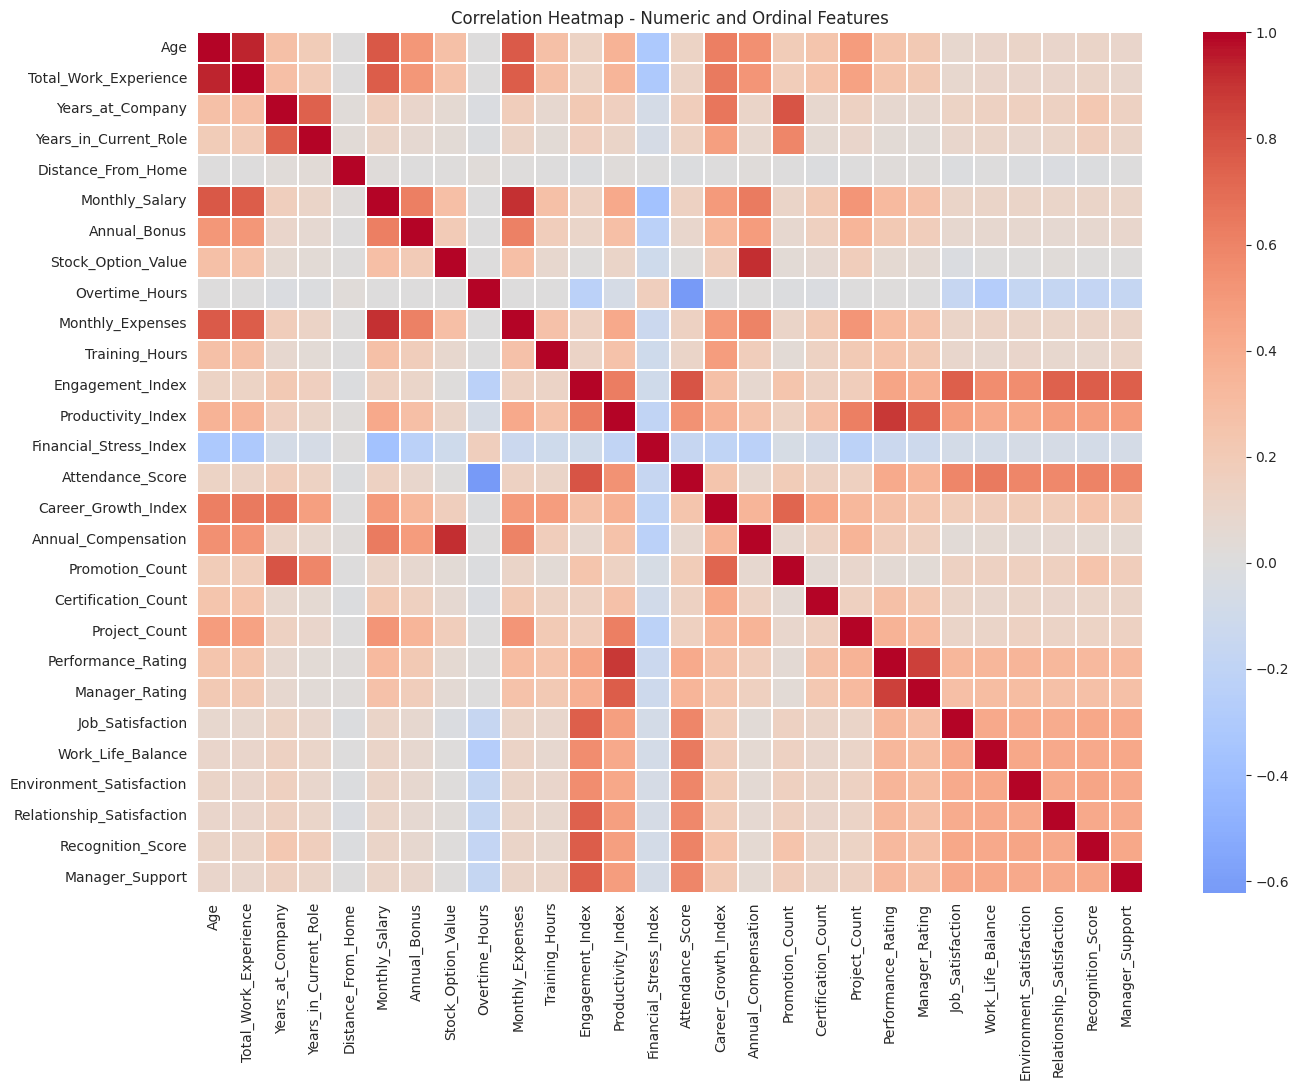

In [16]:
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, ax=ax, linewidths=0.3)
ax.set_title('Correlation Heatmap - Numeric and Ordinal Features')
plt.tight_layout()
plt.show()


In [17]:
pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = corr.iloc[i, j]
        if abs(v) > 0.6:
            pairs.append((cols[i], cols[j], round(v, 3)))
pairs_df = pd.DataFrame(pairs, columns=['Feature_1', 'Feature_2', 'Correlation']).sort_values(
    'Correlation', key=abs, ascending=False)
pairs_df


,Feature_1,Feature_2,Correlation
0,Age,Total_Work_Experience,0.941
14,Stock_Option_Value,Annual_Compensation,0.917
11,Monthly_Salary,Monthly_Expenses,0.909
24,Productivity_Index,Performance_Rating,0.882
29,Performance_Rating,Manager_Rating,0.863
9,Years_at_Company,Promotion_Count,0.793
18,Engagement_Index,Attendance_Score,0.785
1,Age,Monthly_Salary,0.777
2,Age,Monthly_Expenses,0.770
4,Total_Work_Experience,Monthly_Salary,0.765


In [18]:
reconstructed = df['Monthly_Salary'] * 12 + df['Annual_Bonus'].fillna(0) + df['Stock_Option_Value']
print('corr(Annual_Compensation & (Monthly_Salary*12 + Annual_Bonus + Stock_Option_Value)):',
      round(df['Annual_Compensation'].corr(reconstructed), 4))

print("\n")
print(df.groupby('Experience_Band')['Total_Work_Experience'].agg(['min', 'max', 'mean']).round(2))


corr(Annual_Compensation & (Monthly_Salary*12 + Annual_Bonus + Stock_Option_Value)): 0.9989


                 min  max   mean
Experience_Band                 
Entry              0    5   1.91
Junior             6   10   8.13
Mid               11   20  15.13
Senior            21   41  25.06


**Observation - several multicollinearity clusters emerge:**

1. **Compensation cluster:** The `pairs_df` table above shows `Monthly_Salary`, `Annual_Bonus`, `Stock_Option_Value`, `Monthly_Expenses`, and `Annual_Compensation` are all pairwise correlated above 0.60 (e.g. `Monthly_Salary`-`Monthly_Expenses` alone is r=0.91). The `reconstructed` check goes one step further and shows `Annual_Compensation` specifically is a near-exact deterministic sum of the other three (correlation about 0.999 with the reconstructed feature) - i.e. it isn't just correlated with them, it is mechanically redundant with them.
2. **Experience/tenure cluster:** `pairs_df` shows `Age` and `Total_Work_Experience` correlate at r about 0.94; the `groupby` check above confirms `Experience_Band` is a direct binning of `Total_Work_Experience` (Entry 0-5 yrs, Junior 6-10, Mid 11-20, Senior 21+) - another redundant pairing.
3. **Performance cluster:** `pairs_df` shows `Performance_Rating`, `Manager_Rating`, and `Productivity_Index` are strongly inter-correlated (pairwise r > 0.75).
4. **Engagement/survey cluster:** `pairs_df` shows `Engagement_Index` is strongly correlated with most survey scores (`Job_Satisfaction`, `Manager_Support`, `Relationship_Satisfaction`, `Recognition_Score`, `Attendance_Score`).

These clusters will be delt with in Part C and Part D.

### A.7 Categorical Features vs. Attrition

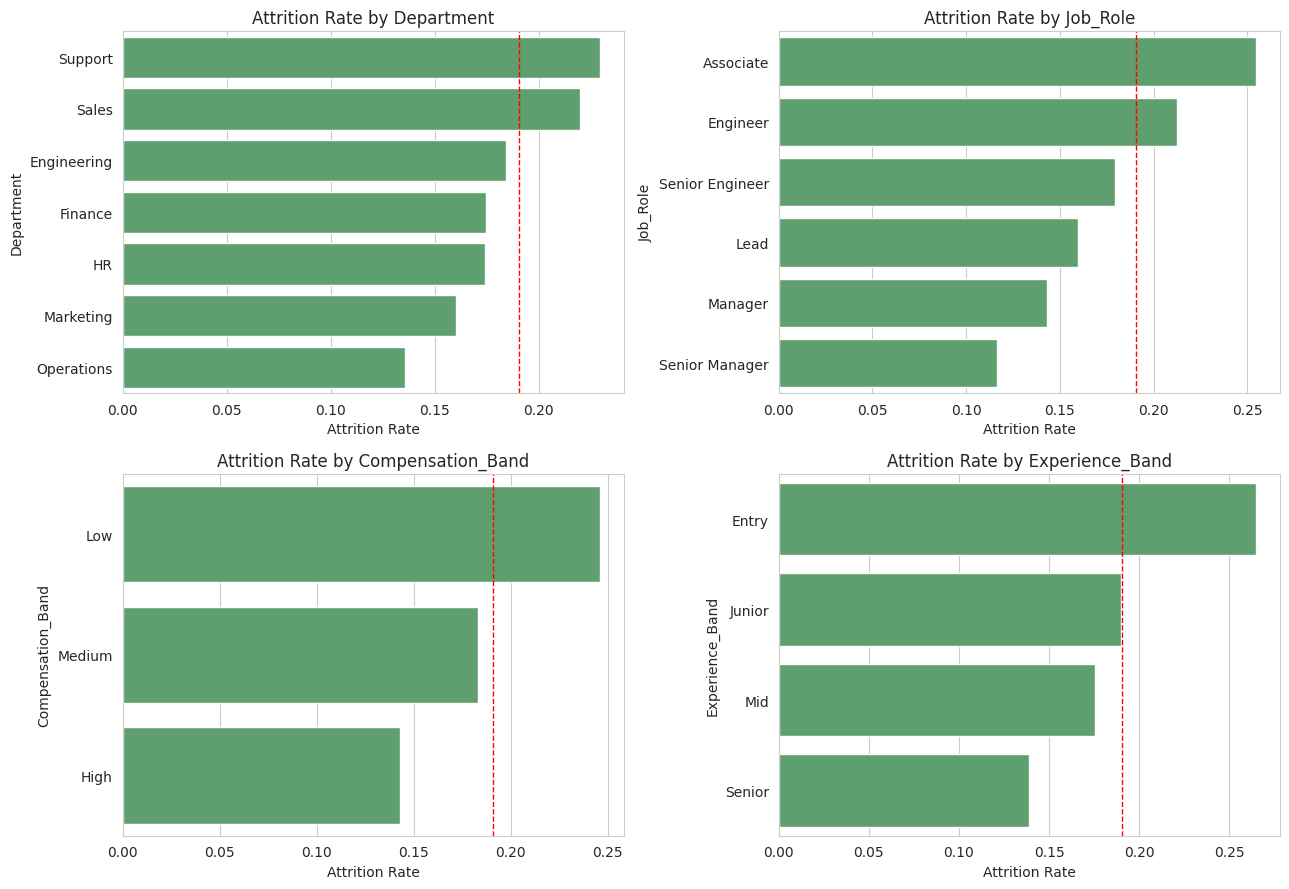

Red dashed line = overall attrition rate


In [19]:
cat_cols = ['Department', 'Job_Role', 'Compensation_Band', 'Experience_Band']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, c in enumerate(cat_cols):
    rates = df.groupby(c)['Attrition'].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=axes[i], color='#55A868')
    axes[i].set_title(f'Attrition Rate by {c}')
    axes[i].set_xlabel('Attrition Rate')
    axes[i].axvline(df['Attrition'].mean(), color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()
print('Red dashed line = overall attrition rate')


**Observation:** Attrition rate varies meaningfully across categories (for example `Experience_Band` Entry vs Senior, `Compensation_Band` Low vs High, `Job_Role` Associate vs Senior Manager). These categorical features carry real signal and are worth keeping and encoding.

### A.8 Data Quality Checks - Duplicates and Logical Consistency

In [20]:
print('Fully duplicated rows:', df.duplicated().sum())
print('Duplicate Employee_ID values:', df['Employee_ID'].duplicated().sum())
print()
print('Rows where Years_in_Current_Role > Years_at_Company:',
      (df['Years_in_Current_Role'] > df['Years_at_Company']).sum())
print('Rows where Years_at_Company > Total_Work_Experience:',
      (df['Years_at_Company'] > df['Total_Work_Experience']).sum())


Fully duplicated rows: 0
Duplicate Employee_ID values: 0

Rows where Years_in_Current_Role > Years_at_Company: 0
Rows where Years_at_Company > Total_Work_Experience: 0


**Observation:**
* No duplicate rows/IDs found.
* Tenure fields are internally consistent. The natural ordering `Years_in_Current_Role <= Years_at_Company <= Total_Work_Experience` is true for every row.

### A.9 Summary of Key Observations (drives Part B-D decisions)

1. No duplicate rows/IDs; tenure fields are internally consistent.
2. Missing values in 4 columns (5-7% each), unrelated to `Attrition` (they seem MCAR), simple imputation is applicable.
3. Target is imbalanced (80.9%/19.1%), noted for downstream modelling, we stratify splits.
4. Compensation/tenure features are strongly right-skewed, they are candidates log-transform.
5. Outliers concentrate in the same skewed features and largely represent real senior/high-earning employees, capping is preferable over deletion.
6. `Annual_Compensation` is redundant with `Monthly_Salary` + `Annual_Bonus` + `Stock_Option_Value`. And `Experience_Band` is a direct binning of `Total_Work_Experience`, both are candidates for removal once their information is captured elsewhere.
7. Four correlated feature clusters (compensation, tenure/experience, performance, engagement/survey), dimensionality reduction worth evaluating.
8. Text-based ordinal features need explicit ordinal encoding, not one-hot.
9. Categorical features carry real signal with respect to attrition, we would keep and encode them.


## Part B - Designing a Feature Engineering Strategy

Based on the observations in Part A, we now design and apply the preprocessing steps. We first split the data into train/test sets (stratified on `Attrition`, since the target is imbalanced) so that every imputation median, capping bound, and scaler is fit only on the training data. This keeps the pipeline honest and reusable on unseen data.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

In [22]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Train shape:', X_train.shape, ', Test shape:', X_test.shape)
print('Train attrition rate:', y_train.mean().round(3), ', Test attrition rate:', y_test.mean().round(3))


Train shape: (4000, 38) , Test shape: (1000, 38)
Train attrition rate: 0.19 , Test attrition rate: 0.191


### B.1 Handling Missing Values

**Decision:** Median imputation for all four columns with missing values.

**Justification:**
* Part A showed missingness is unrelated to `Attrition` (MCAR-like), so a simple, robust imputation is appropriate, we don't need missing-indicator flags or model-based imputation to correct for bias.
* `Annual_Bonus` and `Training_Hours` are continuous, median is robust to the skew observed in `Annual_Bonus` (mean would be pulled by the long right tail).
* `Manager_Rating` and `Environment_Satisfaction` are ordinal Likert scores. We impute with the median and then round, so the imputed value always lands on a valid scale point (on a 1-5 scale, not any decimal value).

**Alternative considered (Not applied):** KNN or regression-based imputation (using other correlated features to predict the missing value), this can be more accurate but adds complexity and a further modelling assumption. But because the missingness is close to random and each column has a low 5-7% missing rate, the added complexity is not justified here.


In [23]:
impute_cols = ['Training_Hours', 'Annual_Bonus', 'Manager_Rating', 'Environment_Satisfaction']

# Imputation values
impute_medians = {c: X_train[c].median() for c in impute_cols}
print('Imputation medians (fit on train):', impute_medians)

Imputation medians (fit on train): {'Training_Hours': 27.1, 'Annual_Bonus': 25752.25, 'Manager_Rating': 3.0, 'Environment_Satisfaction': 5.0}


In [24]:
for c in impute_cols:
    X_train[c] = X_train[c].fillna(impute_medians[c])
    X_test[c] = X_test[c].fillna(impute_medians[c])

# Roundup
X_train['Manager_Rating'] = X_train['Manager_Rating'].round()
X_test['Manager_Rating'] = X_test['Manager_Rating'].round()
X_train['Environment_Satisfaction'] = X_train['Environment_Satisfaction'].round()
X_test['Environment_Satisfaction'] = X_test['Environment_Satisfaction'].round()

print()
print('Remaining nulls in train:', X_train.isnull().sum().sum())
print('Remaining nulls in test:', X_test.isnull().sum().sum())



Remaining nulls in train: 0
Remaining nulls in test: 0


### B.2 Outlier Treatment (Winsorization)

**Decision:** Cap continuous numeric features at the 1st and 99th percentile (computed on train), rather than removing rows.

**Justification:** Part A showed the outliers are concentrated in skewed, real-world features (compensation, tenure) and mostly represent real senior/high-earning employees rather than data errors. Deleting them would both shrink the dataset and remove exactly the employees who may carry attrition signal. Capping preserves every row while limiting the influence of extreme values on scaling and distance-based models.

**Alternative considered:** IQR-based capping (as used for detection in Part A). We use percentile-based capping instead here because it caps a fixed proportion of extreme values consistently across features with different distributions, and is simple to fit/store/reapply in a pipeline.




In [25]:
cap_cols = ['Age', 'Total_Work_Experience', 'Years_at_Company', 'Years_in_Current_Role',
            'Distance_From_Home', 'Monthly_Salary', 'Annual_Bonus', 'Stock_Option_Value',
            'Overtime_Hours', 'Monthly_Expenses', 'Training_Hours', 'Annual_Compensation',
            'Promotion_Count', 'Project_Count']

# Cap bounds
cap_bounds = {c: tuple(X_train[c].quantile([0.01, 0.99])) for c in cap_cols}

In [26]:
before_skew = X_train[cap_cols].skew()

for c in cap_cols:
    lo, hi = cap_bounds[c]
    X_train[c] = X_train[c].clip(lo, hi)
    X_test[c] = X_test[c].clip(lo, hi)

after_skew = X_train[cap_cols].skew()
pd.DataFrame({'skew_before_capping': before_skew, 'skew_after_capping': after_skew}).round(3)


,skew_before_capping,skew_after_capping
Age,0.172,0.104
Total_Work_Experience,0.286,0.226
Years_at_Company,1.174,1.027
Years_in_Current_Role,1.974,1.552
Distance_From_Home,1.823,1.506
Monthly_Salary,1.982,1.285
Annual_Bonus,3.028,1.840
Stock_Option_Value,3.445,2.045
Overtime_Hours,1.607,1.315
Monthly_Expenses,1.647,1.346


**Observation:** Capping alone reduces skew somewhat but several compensation-related features (`Stock_Option_Value`, `Annual_Bonus`, `Monthly_Salary`) remain highly skewed even after capping, since the skew comes from the overall shape of the distribution, not just a handful of extreme points. This confirms a log transform (next step) is still needed on top of capping.

### B.3 Transforming Skewed Numerical Features

**Decision:** Apply `log1p` to features with skewness greater than 1 after capping.

**Justification:** Log transforms compress the long right tail typical of compensation and tenure data, making these features closer to normal, important for linear and distance-based models, and generally beneficial for model stability even with tree-based models.<br>


**Alternative considered:** Plain `log transforms` was an alternative consideration. But due to its inability to handle zero values (e.g. `Years_in_Current_Role` and `Stock_Option_Value` can be 0 for new employees or those without stock options), we used `log1p` insted.



In [27]:
skew_after_cap = X_train[cap_cols].skew().sort_values(ascending=False)
print(skew_after_cap)

Stock_Option_Value       2.044905
Annual_Bonus             1.839768
Years_in_Current_Role    1.551678
Distance_From_Home       1.505973
Annual_Compensation      1.430667
Monthly_Expenses         1.346037
Overtime_Hours           1.315099
Monthly_Salary           1.285258
Years_at_Company         1.026693
Promotion_Count          1.017063
Project_Count            0.556652
Total_Work_Experience    0.226407
Age                      0.104104
Training_Hours           0.003333
dtype: float64


In [28]:
log_transform_cols = skew_after_cap[skew_after_cap > 1].index.tolist()
print()
print('Columns selected for log1p transform (skew > 1 after capping):', log_transform_cols)



Columns selected for log1p transform (skew > 1 after capping): ['Stock_Option_Value', 'Annual_Bonus', 'Years_in_Current_Role', 'Distance_From_Home', 'Annual_Compensation', 'Monthly_Expenses', 'Overtime_Hours', 'Monthly_Salary', 'Years_at_Company', 'Promotion_Count']


In [29]:
for c in log_transform_cols:
    X_train[c] = np.log1p(X_train[c].clip(lower=0))
    X_test[c] = np.log1p(X_test[c].clip(lower=0))

print('Skew after log1p transform:')
print(X_train[log_transform_cols].skew().round(3))


Skew after log1p transform:
Stock_Option_Value       0.416
Annual_Bonus            -0.286
Years_in_Current_Role    0.428
Distance_From_Home      -0.244
Annual_Compensation      0.079
Monthly_Expenses        -0.015
Overtime_Hours          -0.188
Monthly_Salary          -0.003
Years_at_Company        -0.314
Promotion_Count          0.548
dtype: float64


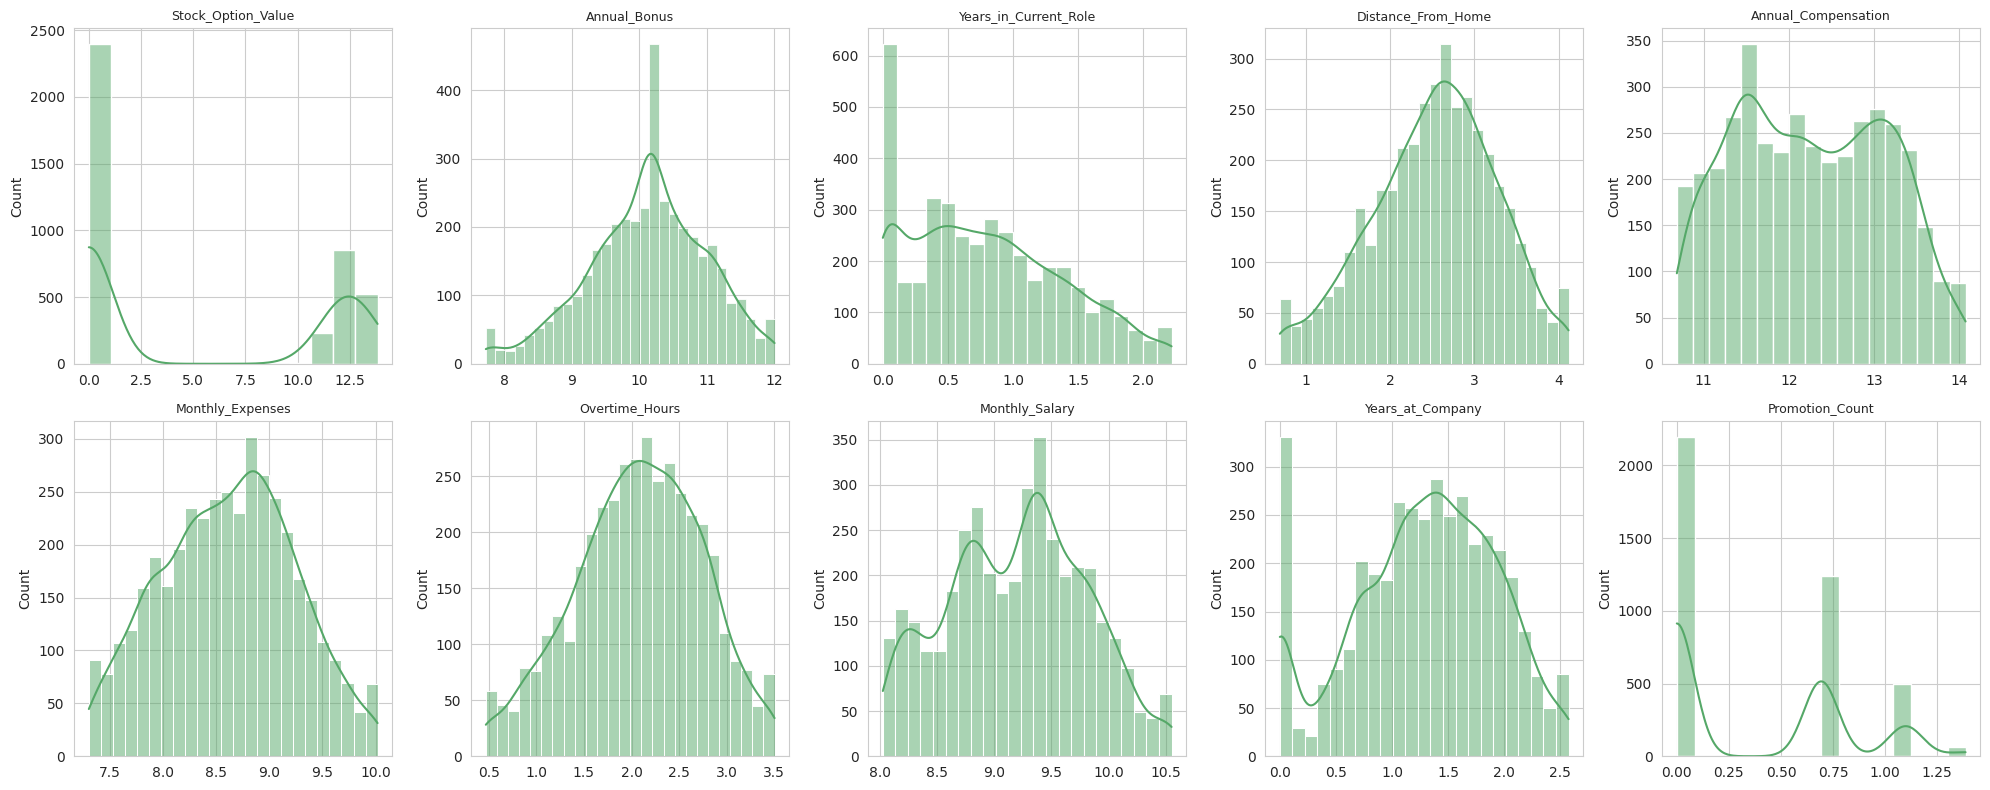

In [30]:
fig, axes = plt.subplots(2, int(len(log_transform_cols)/2), figsize=(20, 8))
axes = axes.flatten()
for i, c in enumerate(log_transform_cols):
    sns.histplot(X_train[c], kde=True, ax=axes[i], color='#55A868')
    axes[i].set_title(c, fontsize=9)
    axes[i].set_xlabel('')
for j in range(len(log_transform_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


**Observation:** After `log1p`, skewness for every selected column drops substantially (most move from the 1.5-3.4 range down toward 0-0.5), confirming the transform achieved its purpose of producing more symmetric distributions sutable for scaling.

### B.4 Encoding Categorical Variables

**Decision:**
- **Nominal columns** (`Gender`, `Marital_Status`, `Department`, `Job_Role`, `Business_Travel`, `Work_Mode`): one-hot encoding. None of these have a natural order, and cardinality is low (3-7 categories each), so one-hot encoding does not create massive number of columns.
- **Text-based ordinal columns** (`Education_Level`, `Compensation_Band`, `Experience_Band`): explicit ordinal encoding with a manually specified order, so that the encoded integers preserve the real-world ranking.
- **Numeric ordinal score columns** (thry are already ordinal integers/floats on 1-5 or 1-10 scales): leave as numeric and scale later, since they are already properly ordered.

**Alternative considered:** Target encoding (replacing each category with its mean attrition rate) for `Job_Role`/`Department`, this can capture more signal but risks target leakage and requires careful cross-validation to avoid overfitting, which adds complexity even though there is low cardinality in these columns (6-7 levels). One-hot / ordinal encoding is simpler, leakage-free, and sufficient here.


In [31]:
nominal_cols_ = ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Business_Travel', 'Work_Mode']
ordinal_text_cols_ = ['Education_Level', 'Compensation_Band', 'Experience_Band']
ordinal_categories_ = [
    ['High School', 'Bachelor', 'Master', 'Doctorate'],
    ['Low', 'Medium', 'High'],
    ['Entry', 'Junior', 'Mid', 'Senior'],
]

In [32]:
one = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
one.fit(X_train[nominal_cols_])
one_train = pd.DataFrame(one.transform(X_train[nominal_cols_]),
                          columns=one.get_feature_names_out(nominal_cols_), index=X_train.index)
print('One-hot encoded columns:', one_train.shape[1])
one_train.head()


One-hot encoded columns: 25


,Gender_Female,Gender_Male,Gender_Non-Binary,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Department_Engineering,Department_Finance,Department_HR,Department_Marketing,Department_Operations,Department_Sales,Department_Support,Job_Role_Associate,Job_Role_Engineer,Job_Role_Lead,Job_Role_Manager,Job_Role_Senior Engineer,Job_Role_Senior Manager,Business_Travel_Frequently,Business_Travel_Never,Business_Travel_Rarely,Work_Mode_Hybrid,Work_Mode_Office,Work_Mode_Remote
2684,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1839,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1473,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3169,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2707,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [33]:
oe = OrdinalEncoder(categories=ordinal_categories_)
oe.fit(X_train[ordinal_text_cols_])
ordinal_train = pd.DataFrame(oe.transform(X_train[ordinal_text_cols_]),
                              columns=ordinal_text_cols_, index=X_train.index)
print('Ordinal encoding preview (0 = lowest level):')
ordinal_train.head()


Ordinal encoding preview (0 = lowest level):


,Education_Level,Compensation_Band,Experience_Band
2684,3.0,0.0,0.0
1839,2.0,0.0,0.0
1473,1.0,0.0,0.0
3169,1.0,0.0,1.0
2707,1.0,0.0,0.0


### B.5 Scaling Numerical Features

**Decision:** `StandardScaler` (zero mean, unit variance), fit on train only, applied to all continuous and discrete numeric columns after imputation, capping, and log-transformation.

**Justification:** After capping and log-transforming the skewed features, most numeric features are reasonably close to symmetric, which is exactly the condition under which standardization is most effective. Standardization is required for any downstream linear or distance-based model (e.g. logistic regression, KNN, SVM) and does not harm tree-based models, making it a safe default for a reusable pipeline that isn't tied to one specific downstream model.

**Alternative considered:** `MinMaxScaler` (0-1 range), more sensitive to any remaining extreme values since it references the min/max directly. Given we've already capped outliers, `StandardScaler` is preferred for its robustness and because it is the more standard choice for features that are now roughly symmetric.


In [34]:
numeric_cols_ = [c for c in cap_cols + ordinal_num_cols if c != 'Total_Work_Experience']

scaler = StandardScaler()
scaler.fit(X_train[numeric_cols_])
scaled_ = pd.DataFrame(scaler.transform(X_train[numeric_cols_]), columns=numeric_cols_, index=X_train.index)
scaled_.describe().T[['mean', 'std']].round(2).head(10)


,mean,std
Age,0.0,1.0
Years_at_Company,-0.0,1.0
Years_in_Current_Role,-0.0,1.0
Distance_From_Home,0.0,1.0
Monthly_Salary,-0.0,1.0
Annual_Bonus,-0.0,1.0
Stock_Option_Value,-0.0,1.0
Overtime_Hours,-0.0,1.0
Monthly_Expenses,0.0,1.0
Training_Hours,-0.0,1.0


**Observation:** After scaling, the preview columns show mean 0 and standard deviation 1, confirming the scaler is behaving as expected. This scaling step, along with the encoding steps above, will be assembled into the final reusable pipeline in Part D (after the feature construction and selection in Part C).

## Part C - Feature Construction and Feature Selection

We restart from a fresh copy of the train/test split (before the encoding done in Part B) so we can build the full construction, selection, encoding sequence in the right order for the final pipeline.


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

for c in impute_cols:
    X_train[c] = X_train[c].fillna(impute_medians[c])
    X_test[c] = X_test[c].fillna(impute_medians[c])
X_train['Manager_Rating'] = X_train['Manager_Rating'].round()
X_test['Manager_Rating'] = X_test['Manager_Rating'].round()
X_train['Environment_Satisfaction'] = X_train['Environment_Satisfaction'].round()
X_test['Environment_Satisfaction'] = X_test['Environment_Satisfaction'].round()

for c in cap_cols:
    lo, hi = cap_bounds[c]
    X_train[c] = X_train[c].clip(lo, hi)
    X_test[c] = X_test[c].clip(lo, hi)

print('Re-applied imputation + capping. Nulls remaining:', X_train.isnull().sum().sum())


Re-applied imputation + capping. Nulls remaining: 0


### C.1 Constructing New Features

We construct features that capture **ratios and interactions** with clear HR business intuition, rather than raw values already present in the data. Each is computed from the capped (but not yet log-transformed) values.


**Tanure Ratio**

In [36]:
X_train['Tenure_Ratio'] = X_train['Years_at_Company'] / (X_train['Total_Work_Experience'] + 1e-3)
X_test['Tenure_Ratio'] = X_test['Years_at_Company'] / (X_test['Total_Work_Experience'] + 1e-3)

**Role Stability Ratio**

In [37]:
X_train['Role_Stability_Ratio'] = X_train['Years_in_Current_Role'] / (X_train['Years_at_Company'] + 1e-3)
X_test['Role_Stability_Ratio'] = X_test['Years_in_Current_Role'] / (X_test['Years_at_Company'] + 1e-3)

**Promotion Rate**

In [38]:
X_train['Promotion_Rate'] = X_train['Promotion_Count'] / (X_train['Years_at_Company'] + 1e-3)
X_test['Promotion_Rate'] = X_test['Promotion_Count'] / (X_test['Years_at_Company'] + 1e-3)

**Compensation Per Experience**

In [39]:
X_train['Compensation_Per_Experience'] = X_train['Annual_Compensation'] / (X_train['Total_Work_Experience'] + 1)
X_test['Compensation_Per_Experience'] = X_test['Annual_Compensation'] / (X_test['Total_Work_Experience'] + 1)

**Commute Burden**

In [40]:
X_train['Commute_Burden'] = X_train['Distance_From_Home'] * (X_train['Work_Mode'] != 'Remote').astype(int)
X_test['Commute_Burden'] = X_test['Distance_From_Home'] * (X_test['Work_Mode'] != 'Remote').astype(int)

In [41]:
new_feats = ['Tenure_Ratio', 'Role_Stability_Ratio', 'Promotion_Rate', 'Compensation_Per_Experience', 'Commute_Burden']
X_train[new_feats].describe().T


,count,mean,std,min,25%,50%,75%,max
Tenure_Ratio,4000.0,0.342949,0.308156,0.0000,0.109989,0.239987,0.499875,9.999167e-01
Role_Stability_Ratio,4000.0,0.457662,0.308687,0.0000,0.190386,0.454133,0.721871,9.998781e-01
Promotion_Rate,4000.0,0.126653,0.155243,0.0000,0.000000,0.000000,0.256345,4.997501e-01
Compensation_Per_Experience,4000.0,29847.676546,48355.017573,4006.9775,11414.898833,18996.818450,33343.424382,1.297640e+06
Commute_Burden,4000.0,11.048025,10.572526,0.0000,3.075000,8.800000,16.000000,6.030000e+01


**Business intuition behind each engineered feature:**

| Feature | Formula | Business meaning |
|---|---|---|
| `Tenure_Ratio` | Years_at_Company / Total_Work_Experience | What fraction of an employee's whole career has been spent at this company - low values flag employees who joined recently relative to their overall experience. |
| `Role_Stability_Ratio` | Years_in_Current_Role / Years_at_Company | How much of an employee's company tenure has been in their current role - a very high value can indicate stagnation (no promotion/role change in a long time), a known attrition driver. |
| `Promotion_Rate` | Promotion_Count / Years_at_Company | Career velocity - promotions earned per year at the company, independent of how long they've been there in absolute terms. |
| `Compensation_Per_Experience` | Annual_Compensation / (Total_Work_Experience + 1) | Whether pay is keeping pace with experience - flags potentially underpaid experienced staff, a classic attrition risk. |
| `Commute_Burden` | Distance_From_Home, zeroed out for Remote workers | The *effective* commute impact - raw distance matters much less if the employee works remotely, so we zero it out for that group instead of letting it inflate the raw distance signal. |


### C.2 Checking the New Features for Newly-Introduced Redundancy

Constructing new features can accidentally introduce new collinearity with existing columns (for example, a feature built as `A - B` will correlate with both `A` and `B`). We should explicitly check this rather than assuming the new features are safe.


In [42]:
candidate_extra = X_train.copy()
candidate_extra['Age_at_Joining'] = candidate_extra['Age'] - candidate_extra['Years_at_Company']
print('corr(Age_at_Joining, Age):', round(candidate_extra['Age_at_Joining'].corr(candidate_extra['Age']), 3))
print('corr(Age_at_Joining, Years_at_Company):', round(candidate_extra['Age_at_Joining'].corr(candidate_extra['Years_at_Company']), 3))


corr(Age_at_Joining, Age): 0.937
corr(Age_at_Joining, Years_at_Company): -0.068


**Observation:** We initially considered an `Age_at_Joining = Age - Years_at_Company` feature. On checking, it correlates 0.94 with `Age` alone, essentially as redundant as the `Age`/`Total_Work_Experience` pair already flagged in Part A, since the spread in `Years_at_Company` is small relative to the spread in `Age`. We therefore **drop this candidate feature**. It does not add independent information beyond `Age`, which we are already keeping.

In [43]:
candidate_extra['Expense_to_Salary_Ratio'] = candidate_extra['Monthly_Expenses'] / candidate_extra['Monthly_Salary']
print('corr(Expense_to_Salary_Ratio, Monthly_Salary):', round(candidate_extra['Expense_to_Salary_Ratio'].corr(candidate_extra['Monthly_Salary']), 3))



corr(Expense_to_Salary_Ratio, Monthly_Salary): -0.045


In [44]:
# With Financial stress
print('corr(Expense_to_Salary_Ratio, Financial_Stress_Index):', round(candidate_extra['Expense_to_Salary_Ratio'].corr(candidate_extra['Financial_Stress_Index']), 3))

corr(Expense_to_Salary_Ratio, Financial_Stress_Index): 0.867


**Observation:** We also considered `Expense_to_Salary_Ratio = Monthly_Expenses / Monthly_Salary` as a way to resolve the `Monthly_Salary` - `Monthly_Expenses` collinearity (r=0.91) found in Part A. While it does break that specific correlation (r=-0.04 with `Monthly_Salary`), it turns out to correlate 0.86 with the already-existing `Financial_Stress_Index` column i.e. it would just be duplicating information the dataset already provides under a different name. We therefore **drop this candidate feature too**, and instead resolve the original `Monthly_Salary`/`Monthly_Expenses` redundancy directly by removing `Monthly_Expenses` in section C.3, relying on `Financial_Stress_Index` to represent financial strain.

### C.3 Identifying Redundant and Less-Informative Features

We now decide what to remove, combining the correlation evidence from Part A with the checks above.


**Columns to drop and Reason:**<br>
* **Employee_ID:** Identifier column, carries no predictive information.
* **Annual_Compensation:** Near-perfectly reconstructable from Monthly_Salary, Annual_Bonus, and Stock_Option_Value (corr ~0.999), redundant composite.
* **Total_Work_Experience:** Correlates 0.94 with Age, and is also the raw basis for Experience_Band (which we keep as the categorical summary), dropping the raw column avoids double-counting this information.
* **Distance_From_Home:** Superseded by the engineered Commute_Burden feature, which captures the same distance signal but zeroed out for remote workers. A more business-accurate version of the same information.
* **Monthly_Expenses:** Correlates 0.91 with Monthly_Salary (redundant), and our attempt to resolve this via a ratio feature showed the useful signal is already captured by Financial_Stress_Index.


In [45]:
to_drop = ['Employee_ID','Annual_Compensation','Total_Work_Experience','Distance_From_Home','Monthly_Expenses']

Another Correlation check

In [46]:
corr_check = X_train[['Performance_Rating', 'Manager_Rating', 'Productivity_Index']].corr()
print(corr_check.round(3))
print()
print('corr(Performance_Rating, Attrition):', round(X_train['Performance_Rating'].corr(y_train), 3))
print('corr(Manager_Rating, Attrition):', round(X_train['Manager_Rating'].corr(y_train), 3))
print('corr(Productivity_Index, Attrition):', round(X_train['Productivity_Index'].corr(y_train), 3))


                    Performance_Rating  Manager_Rating  Productivity_Index
Performance_Rating               1.000           0.842               0.883
Manager_Rating                   0.842           1.000               0.744
Productivity_Index               0.883           0.744               1.000

corr(Performance_Rating, Attrition): -0.117
corr(Manager_Rating, Attrition): -0.083
corr(Productivity_Index, Attrition): -0.173


**Observation:** `Performance_Rating`, `Manager_Rating`, and `Productivity_Index` are all strongly inter-correlated (r > 0.75 pairwise), essentially three measurements of the same underlying "performance" concept. `Productivity_Index` is the most granular (continuous, not a 1-5 rating) and has the strongest correlation with `Attrition`, so we keep it and drop both `Performance_Rating` and `Manager_Rating`.

**Columns to drop and Reason:**<br>
* **Manager_Rating:** Redundant with Productivity_Index/Performance_Rating (r>0.75). Productivity_Index is kept as the more granular signal.
* **Performance_Rating:** Same performance cluster as Manager_Rating/Productivity_Index. Productivity_Index is more granular and more correlated with Attrition.

In [47]:
to_drop.extend(['Manager_Rating', 'Performance_Rating'])

In [48]:
print('Final drop list:')
for f in to_drop:
    print('*', f)

Final drop list:
* Employee_ID
* Annual_Compensation
* Total_Work_Experience
* Distance_From_Home
* Monthly_Expenses
* Manager_Rating
* Performance_Rating


In [49]:
print('Shape before dropping:',X_train.shape)
print()
X_train_c = X_train.drop(columns=to_drop)
X_test_c = X_test.drop(columns=to_drop)
print()
print('Shape after dropping redundant columns:', X_train_c.shape)


Shape before dropping: (4000, 43)


Shape after dropping redundant columns: (4000, 36)


### C.4 Re-checking Multicollinearity After Selection

We re-run the same correlation check from Part A on the reduced, engineered feature set to confirm the redundancy has actually been resolved (rather than assuming it worked).<br> This time we set the `Threshold to r>0.75`


In [50]:
num_check_cols = X_train_c.select_dtypes(include='number').columns.tolist()
corr_final = X_train_c[num_check_cols].corr()

In [51]:
pairs_final = []
cols = corr_final.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = corr_final.iloc[i, j]
        if abs(v) > 0.75:
            pairs_final.append((cols[i], cols[j], round(v, 3)))
pairs_final_df = pd.DataFrame(pairs_final, columns=['Feature_1', 'Feature_2', 'Correlation']).sort_values(
    'Correlation', key=abs, ascending=False)
pairs_final_df


,Feature_1,Feature_2,Correlation
0,Age,Monthly_Salary,0.802
2,Promotion_Count,Promotion_Rate,0.802
1,Years_at_Company,Promotion_Count,0.795
5,Engagement_Index,Attendance_Score,0.785
4,Recognition_Score,Engagement_Index,0.758
3,Job_Satisfaction,Engagement_Index,0.753


**Observation:** The remaining pairs above 0.75 fall into two groups:
- **Engagement/survey cluster** (`Engagement_Index`, `Attendance_Score`, `Recognition_Score`, etc.), intentionally left inter-correlated here, since Part D applies PCA specifically to this cluster rather than removing individual columns by hand.
- **`Promotion_Count` / `Promotion_Rate`** and **`Years_at_Company` / `Promotion_Count`**, these are conceptually distinct (absolute promotions earned vs. promotion pace vs. tenure) even though they are correlated, each of them carries genuine, separate business meaning, so we keep both rather than mechanically dropping one just because the correlation crosses a threshold.<br> This reflects a general principle: **correlation alone doesn't automatically mean redundant, redundancy also requires that the features represent the same underlying concept**, which was true for `Annual_Compensation` and the performance-rating trio, but is not true here.

The previously-flagged redundant pairs (`Annual_Compensation` sum, `Age`/`Total_Work_Experience` and the performance trio), no more appear in this list any more, confirming the Part C decisions resolved the multicollinearity identified in Part A.

### C.5 Final Selected Feature Set


In [52]:
final_features = X_train_c.columns.tolist()
print(f'Final feature count: {len(final_features)} (started from {X.shape[1]} raw columns + {len(new_feats)} engineered - {len(to_drop)} dropped)')
print()
for f in final_features:
    print('*', f)


Final feature count: 36 (started from 38 raw columns + 5 engineered - 7 dropped)

* Age
* Gender
* Marital_Status
* Education_Level
* Department
* Job_Role
* Years_at_Company
* Years_in_Current_Role
* Promotion_Count
* Business_Travel
* Work_Mode
* Monthly_Salary
* Annual_Bonus
* Stock_Option_Value
* Overtime_Hours
* Compensation_Band
* Training_Hours
* Certification_Count
* Project_Count
* Job_Satisfaction
* Work_Life_Balance
* Environment_Satisfaction
* Relationship_Satisfaction
* Recognition_Score
* Manager_Support
* Engagement_Index
* Productivity_Index
* Financial_Stress_Index
* Attendance_Score
* Career_Growth_Index
* Experience_Band
* Tenure_Ratio
* Role_Stability_Ratio
* Promotion_Rate
* Compensation_Per_Experience
* Commute_Burden


## Part D - Dimensionality Reduction and Pipeline Design

In [53]:
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



### D.1 Assessing Whether Dimensionality Reduction Is Beneficial

The dataset has a moderate number of features (35 after Part C, before one-hot expansion), not high-dimensional which neccessarly demands aggressive reduction. Most of the multicollinearity identified in Part A has already been resolved through direct feature removal in Part C, since those cases were genuine redundancy (one feature is a near-exact function of others).

The one cluster we deliberately left untouched in Part C is the **engagement/survey cluster** - `Job_Satisfaction`, `Work_Life_Balance`, `Environment_Satisfaction`, `Relationship_Satisfaction`, `Recognition_Score`, `Manager_Support`, `Engagement_Index`, `Attendance_Score`. These are correlated with each other but each is a distinct survey question, not a mechanical function of the others, so simple removal isn't clearly justified the way it was for `Annual_Compensation`. This is exactly the situation PCA is suited for: multiple correlated measurements of a related underlying concept.

We evaluate PCA on this cluster specifically, rather than across the whole dataset, to avoid sacrificing interpretability on the many features where dimensionality reduction isn't needed.

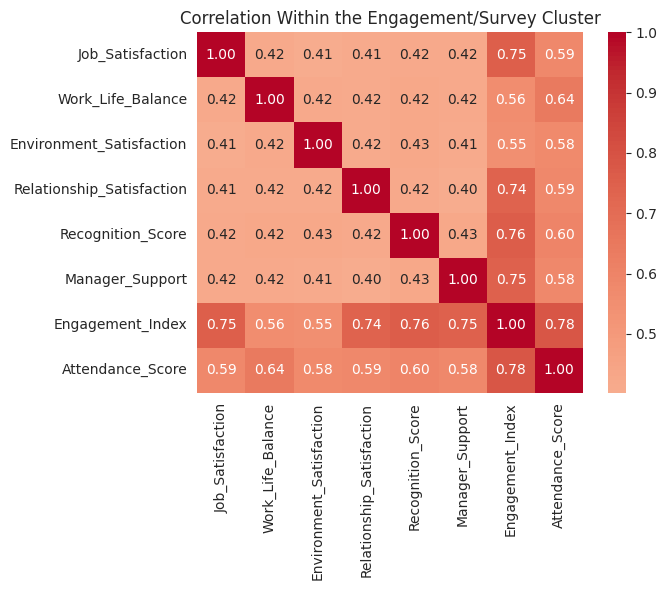

In [54]:
engagement_cluster_cols = ['Job_Satisfaction', 'Work_Life_Balance', 'Environment_Satisfaction',
                           'Relationship_Satisfaction', 'Recognition_Score', 'Manager_Support',
                           'Engagement_Index', 'Attendance_Score']

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(X_train_c[engagement_cluster_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Within the Engagement/Survey Cluster')
plt.tight_layout()
plt.show()


In [55]:
engagement_scaler = StandardScaler()
engagement_scaled = engagement_scaler.fit_transform(X_train_c[engagement_cluster_cols])
pca_full = PCA(random_state=RANDOM_STATE).fit(engagement_scaled)

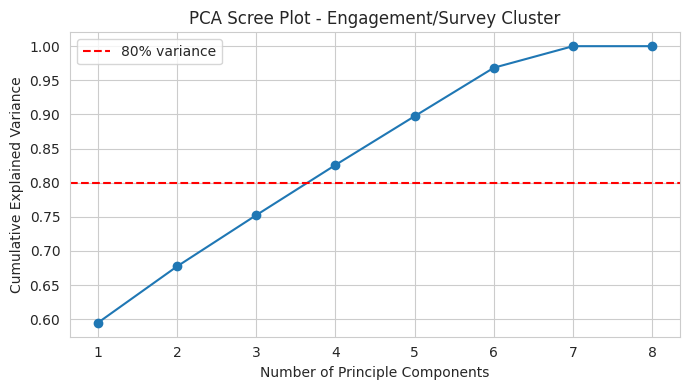

Explained variance ratio per component: [0.595 0.083 0.075 0.074 0.072 0.071 0.032 0.   ]
Cumulative: [0.595 0.677 0.752 0.826 0.897 0.968 1.    1.   ]


In [56]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
        np.cumsum(pca_full.explained_variance_ratio_), marker='o')
ax.axhline(0.8, color='red', linestyle='--', label='80% variance')
ax.set_xlabel('Number of Principle Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Scree Plot - Engagement/Survey Cluster')
ax.legend()
plt.tight_layout()
plt.show()

print('Explained variance ratio per component:', np.round(pca_full.explained_variance_ratio_, 3))
print('Cumulative:', np.round(np.cumsum(pca_full.explained_variance_ratio_), 3))


**Observation:** The first component alone explains about 59% of the variance in this cluster, a clear dominant general factor. After that, variance drops off gradually rather than sharply (each further component adds roughly 7-8%), meaning the remaining structure is fairly spread out rather than concentrated in one or two more components. Reaching 80% cumulative variance would require 4 components, which is not a large reduction from the original 8 columns.

**Decision:** We keep 2 principal components. This captures the dominant shared signal (about 68% of variance) while meaningfully reducing 8 correlated columns down to 2 uncorrelated ones. A reasonable trade-off between interpretability and information retention.


In [57]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(engagement_scaled)
loadings = pd.DataFrame(pca_2.components_.T, index=engagement_cluster_cols, columns=['PC1', 'PC2'])
print('Explained variance (2 components):', np.round(pca_2.explained_variance_ratio_, 3),
      ', Explained variance total:', round(pca_2.explained_variance_ratio_.sum(), 3))
loadings.round(3)


Explained variance (2 components): [0.595 0.083] , Explained variance total: 0.677


,PC1,PC2
Job_Satisfaction,0.332,-0.320
Work_Life_Balance,0.319,0.592
Environment_Satisfaction,0.311,0.560
Relationship_Satisfaction,0.330,-0.177
Recognition_Score,0.337,-0.144
Manager_Support,0.331,-0.254
Engagement_Index,0.443,-0.298
Attendance_Score,0.403,0.165


**Interpreting the components (from the loadings above):**
* **PC1** loads positively and fairly evenly across all eight columns (roughly 0.3-0.44 each). This is a general **"overall engagement/sentiment"** factor: employees who score high on one survey dimension tend to score high across the board.
* **PC2** loads strongly positive on `Work_Life_Balance` and `Environment_Satisfaction`, and negative on `Job_Satisfaction`, `Relationship_Satisfaction`, and `Engagement_Index`. This contrasts **workplace-environment/balance satisfaction** against **job/social engagement satisfaction**, i.e. it separates employees who are comfortable with their environment and hours but less engaged with the work/people, from the opposite pattern.

This gives the two components a genuine business interpretation, rather than being an opaque black-box reduction.


### D.2 Building the Reusable Preprocessing Pipeline

We now assemble every decision from Parts B-D into a single scikit-learn `Pipeline` that can be fit once on training data and reapplied identically to any new raw data (e.g. new hires, a future quarter's export) with a single `.transform()` call.

The pipeline has two stages:
1. **`HRFeatureEngineer`** - a custom transformer performing imputation, capping, feature construction, log-transforms, and redundant-column removal (all pandas-based, since these steps involve creating/dropping columns by name).
2. **`ColumnTransformer`** - encoding (one-hot / ordinal), scaling, and the engagement-cluster PCA, applied to the output of step 4.1.


In [58]:
IMPUTE_COLS = ['Training_Hours', 'Annual_Bonus', 'Manager_Rating', 'Environment_Satisfaction']

CAP_COLS = ['Age', 'Total_Work_Experience', 'Years_at_Company', 'Years_in_Current_Role',
            'Distance_From_Home', 'Monthly_Salary', 'Annual_Bonus', 'Stock_Option_Value',
            'Overtime_Hours', 'Monthly_Expenses', 'Training_Hours', 'Annual_Compensation',
            'Promotion_Count', 'Project_Count']

LOG_COLS = ['Stock_Option_Value', 'Annual_Bonus', 'Monthly_Salary', 'Years_in_Current_Role',
            'Years_at_Company', 'Overtime_Hours', 'Commute_Burden', 'Compensation_Per_Experience']

DROP_COLS = ['Employee_ID', 'Annual_Compensation', 'Total_Work_Experience', 'Manager_Rating',
             'Performance_Rating', 'Distance_From_Home', 'Monthly_Expenses']


class HRFeatureEngineer(BaseEstimator, TransformerMixin):
    """Encapsulates Parts B and C: imputation, outlier capping, feature construction,
    skew correction, and redundant-column removal. All bounds/medians are learned
    in fit() from training data only, then reused in transform(), making the
    pipeline safe to apply to new, unseen data without leakage."""

    def fit(self, X, y=None):
        X = X.copy()
        self.impute_medians_ = {c: X[c].median() for c in IMPUTE_COLS}
        X_imputed = X.copy()
        for c in IMPUTE_COLS:
            X_imputed[c] = X_imputed[c].fillna(self.impute_medians_[c])
        self.cap_bounds_ = {c: tuple(X_imputed[c].quantile([0.01, 0.99])) for c in CAP_COLS}
        return self

    def transform(self, X):
        X = X.copy()
        for c in IMPUTE_COLS:
            X[c] = X[c].fillna(self.impute_medians_[c])
        X['Manager_Rating'] = X['Manager_Rating'].round()
        X['Environment_Satisfaction'] = X['Environment_Satisfaction'].round()

        for c in CAP_COLS:
            lo, hi = self.cap_bounds_[c]
            X[c] = X[c].clip(lo, hi)

        X['Tenure_Ratio'] = X['Years_at_Company'] / (X['Total_Work_Experience'] + 1e-3)
        X['Role_Stability_Ratio'] = X['Years_in_Current_Role'] / (X['Years_at_Company'] + 1e-3)
        X['Promotion_Rate'] = X['Promotion_Count'] / (X['Years_at_Company'] + 1e-3)
        X['Compensation_Per_Experience'] = X['Annual_Compensation'] / (X['Total_Work_Experience'] + 1)
        X['Commute_Burden'] = X['Distance_From_Home'] * (X['Work_Mode'] != 'Remote').astype(int)

        for c in LOG_COLS:
            X[c] = np.log1p(X[c].clip(lower=0))

        X = X.drop(columns=DROP_COLS)
        return X

    def get_feature_names_out(self, input_features=None):
        return None

In [59]:
fe_check = HRFeatureEngineer()
Xt_train_check = fe_check.fit_transform(X)
print('Feature-engineered shape:', Xt_train_check.shape)
print('Nulls remaining:', Xt_train_check.isnull().sum().sum())
Xt_train_check.head()


Feature-engineered shape: (5000, 36)
Nulls remaining: 0


,Age,Gender,Marital_Status,Education_Level,Department,Job_Role,Years_at_Company,Years_in_Current_Role,Promotion_Count,Business_Travel,Work_Mode,Monthly_Salary,Annual_Bonus,Stock_Option_Value,Overtime_Hours,Compensation_Band,Training_Hours,Certification_Count,Project_Count,Job_Satisfaction,Work_Life_Balance,Environment_Satisfaction,Relationship_Satisfaction,Recognition_Score,Manager_Support,Engagement_Index,Productivity_Index,Financial_Stress_Index,Attendance_Score,Career_Growth_Index,Experience_Band,Tenure_Ratio,Role_Stability_Ratio,Promotion_Rate,Compensation_Per_Experience,Commute_Burden
0,37,Male,Single,Bachelor,Engineering,Senior Engineer,2.174752,1.791759,2,Frequently,Hybrid,9.308701,9.765554,11.928245,1.740466,Medium,35.1,3,3,6,5,7.0,6,7,7,6.50,53.59,44.11,92.84,52.99,Mid,0.519965,0.640943,0.256377,9.843319,3.005683
1,27,Male,Single,Bachelor,Operations,Engineer,1.098612,0.095310,0,Never,Office,8.691975,9.581600,0.000000,2.468100,Low,27.1,0,1,6,5,5.0,5,5,5,5.25,39.22,85.62,88.21,14.41,Entry,0.999500,0.049975,0.000000,10.262848,1.960095
2,41,Male,Married,Master,Finance,Manager,1.740466,0.182322,1,Frequently,Hybrid,10.001294,9.883956,12.355453,0.832909,High,31.8,0,8,6,4,6.0,4,9,4,5.75,49.53,36.18,90.69,36.18,Mid,0.313312,0.042544,0.212721,10.382238,1.774952
3,43,Male,Divorced,Bachelor,Finance,Manager,1.386294,0.587787,0,Never,Hybrid,10.204868,11.829148,11.624553,0.832909,High,31.6,0,8,6,6,5.0,6,6,8,6.50,59.97,50.70,89.36,31.91,Senior,0.130429,0.266578,0.000000,10.081332,2.772589
4,21,Male,Single,Bachelor,HR,Associate,0.000000,0.000000,0,Rarely,Hybrid,8.087803,8.349893,0.000000,1.481605,Low,20.4,0,2,5,4,5.0,4,5,4,4.50,39.32,44.69,90.01,14.34,Entry,0.000000,0.000000,0.000000,10.682280,2.815409


With the feature-engineering stage confirmed, we now define the `ColumnTransformer` for encoding, scaling, and the engagement-cluster PCA, and combine both stages into the final pipeline.


In [60]:
nominal_cols_final = ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Business_Travel', 'Work_Mode']
ordinal_text_cols_final = ['Education_Level', 'Compensation_Band', 'Experience_Band']
ordinal_categories_final = [
    ['High School', 'Bachelor', 'Master', 'Doctorate'],
    ['Low', 'Medium', 'High'],
    ['Entry', 'Junior', 'Mid', 'Senior'],
]
engagement_cluster_cols_final = ['Job_Satisfaction', 'Work_Life_Balance', 'Environment_Satisfaction',
                                  'Relationship_Satisfaction', 'Recognition_Score', 'Manager_Support',
                                  'Engagement_Index', 'Attendance_Score']

remaining_numeric_final = [c for c in Xt_train_check.columns   # Remaining numeric columns
                           if c not in nominal_cols_final + ordinal_text_cols_final + engagement_cluster_cols_final]

preprocessor = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols_final),
    ('ordinal', OrdinalEncoder(categories=ordinal_categories_final), ordinal_text_cols_final),
    ('engagement_pca', Pipeline([
        ('scale', StandardScaler()),
        ('pca', PCA(n_components=2, random_state=RANDOM_STATE)),
    ]), engagement_cluster_cols_final),
    ('numeric_scale', StandardScaler(), remaining_numeric_final),
])

hr_pipeline = Pipeline([
    ('feature_engineering', HRFeatureEngineer()),
    ('preprocessing', preprocessor),
])

hr_pipeline


Pipeline(steps=[('feature_engineering', HRFeatureEngineer()),
                ('preprocessing',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender', 'Marital_Status',
                                                   'Department', 'Job_Role',
                                                   'Business_Travel',
                                                   'Work_Mode']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['High '
                                                                              'School',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'Doctorate'],
                                                                             [...
                                                  ['Age', 'Years_at_Company',
                                                   'Years_in_Current_Role',
                                                   'Promotion_Count',
                                                   'Monthly_Salary',
                                                   'Annual_Bonus',
                                                   'Stock_Option_Value',
                                                   'Overtime_Hours',
                                                   'Training_Hours',
                                                   'Certification_Count',
                                                   'Project_Count',
                                                   'Productivity_Index',
                                                   'Financial_Stress_Index',
                                                   'Career_Growth_Index',
                                                   'Tenure_Ratio',
                                                   'Role_Stability_Ratio',
                                                   'Promotion_Rate',
                                                   'Compensation_Per_Experience',
                                                   'Commute_Burden'])]))])

### D.3 Validating the Pipeline End-to-End

We fit the pipeline on the training split only, then apply it (via `.transform()`, no re-fitting) to the untouched test split, confirming it generalizes correctly to data it has never seen. To test if pipeline is genuinely reusable.


In [61]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

Xt_train_final = hr_pipeline.fit_transform(X_train_final)
Xt_test_final = hr_pipeline.transform(X_test_final)

print('Transformed train shape:', Xt_train_final.shape)
print('Transformed test shape:', Xt_test_final.shape)
print('Any NaNs in train:', np.isnan(Xt_train_final).sum())
print('Any NaNs in test:', np.isnan(Xt_test_final).sum())


Transformed train shape: (4000, 49)
Transformed test shape: (1000, 49)
Any NaNs in train: 0
Any NaNs in test: 0


**Observation:** The pipeline transforms both the training data (used to fit it) and the completely held-out test data into the same numeric, model-ready shape with zero missing values, using only statistics learned from the training set. This confirms the pipeline is reusable: it can be fit once and applied to any new raw HR export in the same format, e.g. `hr_pipeline.transform(new_employee_batch)`, without needing to repeat any of the manual analysis above.

In [62]:
import joblib
joblib.dump(hr_pipeline, 'hr_feature_engineering_pipeline.joblib')
print('Pipeline saved to hr_feature_engineering_pipeline.joblib - can be reloaded with joblib.load(...) and reused directly.')


Pipeline saved to hr_feature_engineering_pipeline.joblib - can be reloaded with joblib.load(...) and reused directly.


## Part E - Summary and Reflection

### Key Feature Engineering Decisions

1. **Imputation:** Median imputation (with rounding for ordinal columns) for the four features with 5-7% missing values, since Part A showed the missingness was unrelated to `Attrition` (MCAR-like). A simple approach was justified rather than a more complex model-based one.
2. **Outlier handling:** Percentile-based capping (1st/99th) rather than deletion, since outliers were concentrated in real, informative senior/high-earning employees rather than data errors.
3. **Skew correction:** `log1p` transforms on features with skew > 1 after capping, to make compensation and tenure features closer to symmetric for downstream scaling and modelling.
4. **Encoding:** Nominal columns were one-hot encoded, while `Education_Level`, `Compensation_Band`, and `Experience_Band` were given explicit ordinal encoding with a manually specified order. One-hot encoding these three would have discarded the natural ranking they carry, which seemed like an unnecessary loss of information.
5. **Feature construction:** Five ratio and interaction features were built based on HR business logic, ehich are `Tenure_Ratio`, `Role_Stability_Ratio`, `Promotion_Rate`, `Compensation_Per_Experience`, and `Commute_Burden`. Two other candidate features were tried first but dropped after it became clear they largely duplicated information already present elsewhere in the data.
6. **Feature selection:** Seven columns were removed; `Employee_ID`, `Annual_Compensation`, `Total_Work_Experience`, `Distance_From_Home`, `Monthly_Expenses`, `Manager_Rating`, and `Performance_Rating` based on clear evidence of redundancy. Rather than assuming this resolved the multicollinearity identified earlier, the correlations were re-checked afterward to confirm it actually had.
7. **Dimensionality reduction:** PCA was applied selectively, using two components on the engagement/survey cluster only, rather than across the dataset as a whole. This kept the rest of the features interpretable while still compressing the survey measurements that were genuinely redundant with one another.

### Challenges Encountered

* A couple of engineered features looked useful going in, but didn't hold up once checked against correlations. `Age_at_Joining` turned out to just be tracking `Age`, and `Expense_to_Salary_Ratio` was largely restating `Financial_Stress_Index` under a different name. Neither would have been caught without going back and comparing each new feature to what already existed in the dataset; making business sense on paper isn't the same as adding new information.

* *Which* correlated features to drop was a less straightforward decision, than just spotting the correlation itself. It required judging whether a pair represented essentially the same underlying concept, in which case removing one was safe, or two genuinely distinct concepts that happened to be related, in which case both were worth keeping with justification, such as `Promotion_Count` and `Promotion_Rate` being a good example of the latter.

* Settling on how many PCA components to retain for the engagement cluster involved a real trade-off. The scree plot didn't show a sharp elbow, so retaining 2 components came down to a judgment call, weighing how much variance was preserved against the benefit of keeping the reduction simple and easy to interpret.

### Benefits of the Final Pipeline

* **Leakage-free and reusable:** Every learned quantity like imputation medians, capping bounds, encoders, scaler, PCA, is fit only on training data. inside a single `scikit-learn` `Pipeline` and `ColumnTransformer` used withen it. And this pipeline can be applied to new raw HR data with one `.transform()` call.
* **Reduced dimensionality with preserved interpretability:** The redundant columns were removed with proper justification rather than applying global PCA, so most of the remaining features are still directly interpretable to an HR audience. Only the genuinely overlapping survey cluster was compressed.
* **Robust to skew and outliers:** Due to capping and log-transforms the numeric features are well-suited for a wide range of models that could be used like, linear, distance-based, or tree-based.
* **Business-relevant engineered features:** The five new ratio and interaction features that were created capture HR concepts (career velocity, role stagnation, pay-experience alignment, effective commute burden) that raw columns don't directly express.

### Assumptions and Limitations

* We assumed the missingness in the four incomplete columns is close to random (MCAR), based on similar attrition rates between missing and non-missing groups. If the true missingness mechanism is more complex (e.g. tied to a variable not in this dataset), median imputation could still introduce some bias.
* Percentile-based capping at the 1st/99th percentile is a fixed choice. A different business context might justify different thresholds (e.g. capping only the upper tail for compensation features).
* The 2-component PCA choice for the engagement cluster retains about 68% of that cluster's variance. A deliberate simplicity/interpretability trade-off, not the objectively "correct" number of components.
* This pipeline was designed and validated on a single train/test split of the provided dataset; before production use, it would be worth re-validating capping bounds and imputation medians periodically as real HR data drifts over time.
